# CDC WONDER — alcohol-induced mortality via `WonderClient`

CDC **WONDER** (`wonder.cdc.gov`) answers mortality queries through an XML-POST web
service. It carries series the Socrata portal does **not** — notably the NCHS
**"alcohol-induced causes"** recode — so it's the source for the immiseration
alcohol-death leg.

`navi`'s `WonderClient` (`lib/clients/wonder.py`) wraps it: it POSTs a `request_xml`
with a browser TLS fingerprint (`curl_cffi` — plain requests get an Akamai 403),
selects the cause via the **ICD-10 codeset finder** (`O_ucd=V2` + `F_.V2=<codes>`),
groups **by year**, and returns the **age-adjusted** rate. The API is national-only
and rate-limited (~1 query / 2 min), so this notebook caches the one call it makes.

**Verified:** the D76 (1999–2020) result reproduces NCHS Data Brief 448 exactly
(2019 = 10.4, 2020 = 13.1 per 100,000).

In [1]:
from pathlib import Path
import json
from datetime import datetime

import numpy
from matplotlib import pyplot

from lib import config
from lib.plots import curve, comparison
from lib.clients import WonderClient
from lib.clients.wonder import _build_request_xml

pyplot.style.use(config.glyfish_style)

# NCHS "Alcohol-Induced Causes" = these 14 underlying-cause ICD-10 codes
# (Data Brief 448 / WONDER UCD help). Filtering the underlying cause to them
# reproduces the published alcohol-induced age-adjusted rate exactly.
ALCOHOL_INDUCED_ICD10 = [
    "E24.4", "F10", "G31.2", "G62.1", "G72.1", "I42.6", "K29.2",
    "K70", "K85.2", "K86.0", "R78.0", "X45", "X65", "Y15",
]

CACHE = Path("data/wonder")          # gitignored, regenerable
CACHE.mkdir(parents=True, exist_ok=True)

## Fetch — cached, two databases stitched

The full series spans two WONDER databases: **D76** (bridged race, 1999–2020) for
history and **D158** (single race, *final*, 2018–2024) for the recent years. Their
2018–2020 overlap agrees exactly, so we take D76 through 2020 and D158 from 2021 on.
WONDER is rate-limited (~1 query / 2 min), so each call is cached under the gitignored
`data/wonder/`; delete a file to force a fresh pull.

In [2]:
async def alcohol_rate(database):
    # Alcohol-induced age-adjusted rate by year (cached; WONDER is throttled).
    path = CACHE / f"alcohol_{database}.json"
    if path.exists():
        return json.loads(path.read_text())
    async with WonderClient() as wonder:
        resp = await wonder.age_adjusted_rate_by_year(
            ALCOHOL_INDUCED_ICD10, database=database,
            title="Alcohol-induced deaths by year (age-adjusted)",
        )
    rows = [row.model_dump() for row in resp.rows]
    path.write_text(json.dumps(rows, indent=2))
    print(f"fetched {len(rows)} rows from WONDER {database}; cached -> {path}")
    return rows

d76 = await alcohol_rate("D76")      # bridged race, 1999-2020
d158 = await alcohol_rate("D158")    # single race, final, 2018-2024

# Stitch: D76 through 2020, D158 from 2021 on (the overlap agrees).
merged = {r["year"]: r for r in d76 if r["year"] <= 2020}
merged.update({r["year"]: r for r in d158 if r["year"] >= 2021})
rows = [merged[y] for y in sorted(merged)]
print(f"stitched {rows[0]['year']}-{rows[-1]['year']} ({len(rows)} years): D76<=2020 + D158>=2021")
rows[-4:]

stitched 1999-2024 (26 years): D76<=2020 + D158>=2021


[{'year': 2021,
  'deaths': 54258,
  'population': 331893745,
  'crude_rate': 16.3,
  'age_adjusted_rate': 14.4},
 {'year': 2022,
  'deaths': 51191,
  'population': 333287557,
  'crude_rate': 15.4,
  'age_adjusted_rate': 13.5},
 {'year': 2023,
  'deaths': 47938,
  'population': 334914895,
  'crude_rate': 14.3,
  'age_adjusted_rate': 12.6},
 {'year': 2024,
  'deaths': 46714,
  'population': 340110988,
  'crude_rate': 13.7,
  'age_adjusted_rate': 12.1}]

### Sanity check — Data Brief 448 + the D76/D158 overlap

In [3]:
by_year = {r["year"]: r for r in rows}
assert by_year[2019]["age_adjusted_rate"] == 10.4   # D76, Data Brief 448
assert by_year[2020]["age_adjusted_rate"] == 13.1   # D76, Data Brief 448
assert by_year[2021]["age_adjusted_rate"] == 14.4   # D158, the peak
# the 2018-2020 overlap agrees across the bridged (D76) and single-race (D158) DBs
assert {r["year"]: r["age_adjusted_rate"] for r in d76 if 2018 <= r["year"] <= 2020} == \
       {r["year"]: r["age_adjusted_rate"] for r in d158 if 2018 <= r["year"] <= 2020}
print("DB448 (2019/2020) ok; 2021 peak =", by_year[2021]["age_adjusted_rate"],
      "; D76/D158 2018-2020 overlap agrees")

DB448 (2019/2020) ok; 2021 peak = 14.4 ; D76/D158 2018-2020 overlap agrees


## U.S. alcohol-induced deaths, age-adjusted — 1999–2024

The steady climb through the 2000s–2010s, the sharp COVID-era jump to the **2021 peak
(14.4)**, then a decline through 2024.

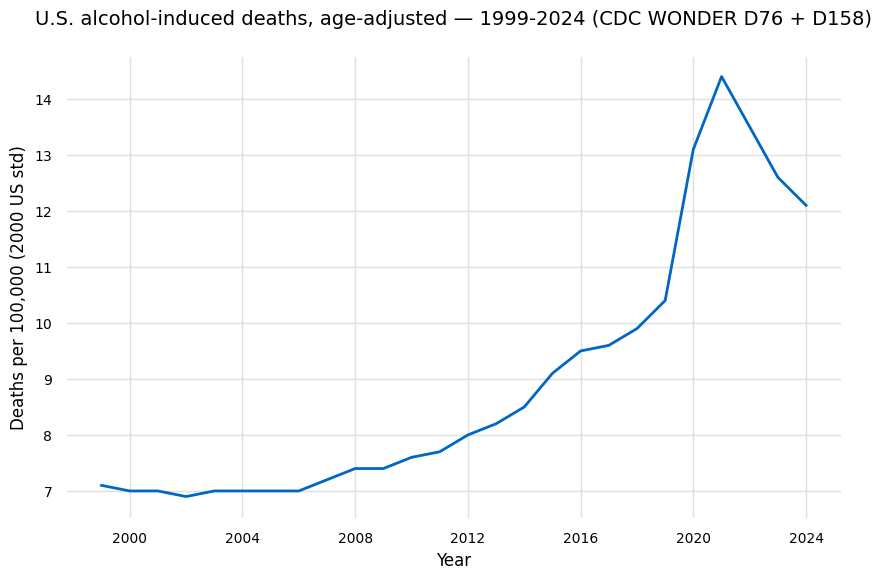

In [4]:
def to_arrays(rows, field):
    pts = [(datetime(r["year"], 1, 1), r[field]) for r in rows if r.get(field) is not None]
    pts.sort()
    return numpy.array([p[1] for p in pts]), numpy.array([p[0] for p in pts])

values, dates = to_arrays(rows, "age_adjusted_rate")
curve(values, dates,
      title="U.S. alcohol-induced deaths, age-adjusted — 1999-2024 (CDC WONDER D76 + D158)",
      xlabel="Year", ylabel="Deaths per 100,000 (2000 US std)")

## Crude vs age-adjusted

The gap is the aging-population correction: age-adjustment holds the age structure
fixed at the 2000 US standard, so crude runs above age-adjusted and the two diverge
as the population ages.

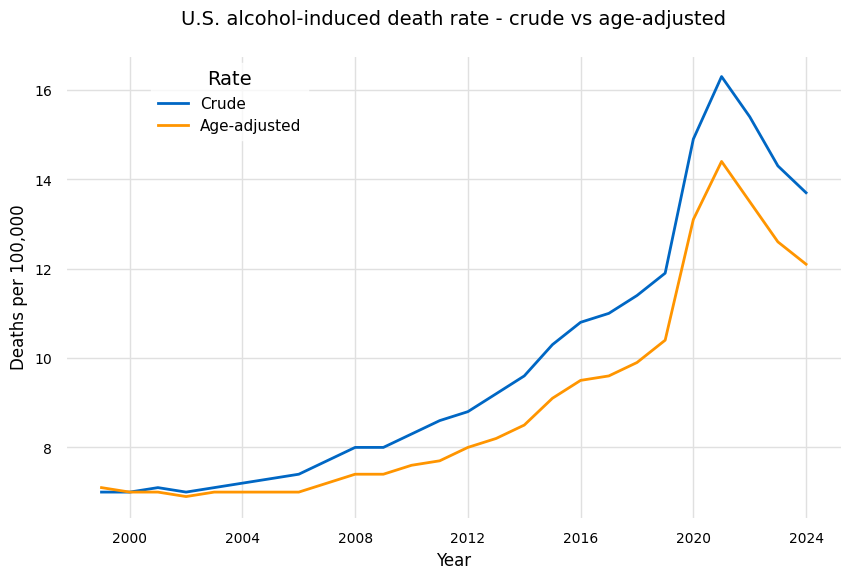

In [5]:
crude = to_arrays(rows, "crude_rate")
aar = to_arrays(rows, "age_adjusted_rate")
comparison([crude[0], aar[0]], [crude[1], aar[1]],
           labels=["Crude", "Age-adjusted"],
           title="U.S. alcohol-induced death rate - crude vs age-adjusted",
           xlabel="Year", ylabel="Deaths per 100,000", legend_title="Rate")

## The recipe — what the client sends

`WonderClient` selects the cause through the ICD-10 **codeset finder** rather than
grouping by the Drug/Alcohol-Induced recode (`B_2=V25`), which returns an HTTP 500
by-variable ordering error. The key parameters of the request:

In [6]:
import xml.etree.ElementTree as ET

req = _build_request_xml("D76", ALCOHOL_INDUCED_ICD10, title="demo")
params = {p.findtext("name", ""): [v.text for v in p.findall("value")]
          for p in ET.fromstring(req)}
for key in ["B_1", "B_2", "O_ucd", "F_D76.V2", "O_aar", "O_aar_pop", "O_rate_per"]:
    print(f"{key:12s} = {params[key]}")

B_1          = ['D76.V1-level1']
B_2          = ['*None*']
O_ucd        = ['D76.V2']
F_D76.V2     = ['E24.4', 'F10', 'G31.2', 'G62.1', 'G72.1', 'I42.6', 'K29.2', 'K70', 'K85.2', 'K86.0', 'R78.0', 'X45', 'X65', 'Y15']
O_aar        = ['aar_std']
O_aar_pop    = ['0000']
O_rate_per   = ['100000']


## Where this goes next

* **Past 2020 — done.** D158 (single race, *final*, 2018–2024) is wired into the client
  and stitched above; its 2018–2020 overlap validates against bridged D76.
* **Drug-induced** — the sibling despair leg is the same recipe with the drug-induced
  ICD-10 code list (same `age_adjusted_rate_by_year`, different codes).
* In the immiseration build the alcohol series becomes an ordered pair of **`wonder`
  segments** (D76 final → D158 final) in the CDC catalog, materialized into
  `immiseration_time_series` alongside the Socrata and NVSR segments.